# AT&T Spam Detector : détection de SMS frauduleux par Deep Learning

**Certification CDSD (RNCP 35288), Bloc 4 : Analyse prédictive de données non structurées**
Marine Deldicque · Jedha Data Science Fullstack

---

## Contexte

AT&T souhaite protéger ses clients contre les SMS frauduleux (spam). L'objectif est de construire
un détecteur qui classe automatiquement chaque SMS en **ham** (légitime) ou **spam**, à partir du
**texte seul**. Le texte est une donnée **non structurée** : il n'a ni colonnes ni valeurs
numériques exploitables directement. Tout l'enjeu du projet est donc de **transformer du texte en
nombres** qu'un réseau de neurones peut apprendre, puis de comparer deux stratégies :

| | Modèle 1 : réseau simple (baseline) | Modèle 2 : DistilBERT (transfer learning) |
|---|---|---|
| Représentation du texte | Embedding **appris de zéro** sur nos SMS | Embeddings contextuels **pré-entraînés** sur des milliards de mots |
| Taille | ~0,3 M de paramètres | ~67 M de paramètres |
| Apprentissage | Entraînement complet | **Fine-tuning** (on ajuste un modèle déjà entraîné) |
| Coût | quelques secondes sur CPU | quelques minutes sur GPU |

## Plan du notebook

1. Chargement et exploration des données (EDA)
2. Découpage train / validation / test
3. Préparation du texte pour le réseau simple (nettoyage, tokenisation, padding)
4. Modèle 1 : Embedding + réseau dense, entraînement et évaluation
5. Ce qu'a appris la couche d'embedding
6. Modèle 2 : DistilBERT, fine-tuning et évaluation
7. Comparaison des deux modèles
8. Choix du seuil de décision (point de vue métier)
9. Analyse des erreurs
10. Conclusion, limites et perspectives

> **Métrique de référence : le F1 de la classe spam.** Le jeu est déséquilibré (≈ 87 % de ham) :
> un modèle qui répond toujours « ham » aurait 87 % d'accuracy tout en ne détectant aucun spam.
> Le F1 spam combine la précision (peu de vrais messages bloqués à tort) et le rappel (peu de spams
> qui passent), c'est-à-dire exactement les deux erreurs qui comptent pour AT&T.

> **Reproductibilité.** Le notebook s'exécute tel quel sur Google Colab (GPU T4) ou en local
> (CPU / Apple Silicon). Le jeu de données est téléchargé automatiquement s'il n'est pas présent.

## 1. Chargement et exploration des données

### 1.1 Environnement et reproductibilité

On fixe une **graine aléatoire** (seed) pour NumPy, TensorFlow et PyTorch : le découpage des données,
l'initialisation des poids et le mélange des batchs deviennent reproductibles d'une exécution à
l'autre. Sans cela, deux exécutions donneraient des scores légèrement différents et la comparaison
des modèles serait bruitée.

In [1]:
# Sur Google Colab, transformers et torch sont préinstallés. En local, décommenter :
# !pip install -q tensorflow torch transformers scikit-learn pandas seaborn

import os
import re
import time
import copy
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, accuracy_score,
                             precision_recall_curve)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

# Accélérateur disponible pour PyTorch (DistilBERT) : GPU NVIDIA > puce Apple (MPS) > CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"TensorFlow {tf.__version__} | PyTorch {torch.__version__} | device PyTorch : {DEVICE}")

TensorFlow 2.21.0 | PyTorch 2.14.0 | device PyTorch : mps


### 1.2 Chargement du jeu de données

Le fichier `spam.csv` (SMS Spam Collection, UCI) est encodé en **latin-1** et contient trois colonnes
vides en plus du label et du texte : on ne garde que les deux premières.

In [2]:
DATA_URL = ("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/"
            "Deep+Learning/project/spam.csv")

candidates = [Path("spam.csv"), Path("/content/spam.csv"), Path("data/spam.csv")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    data_path = Path("spam.csv")
    print("Téléchargement du jeu de données...")
    urllib.request.urlretrieve(DATA_URL, data_path)

df = pd.read_csv(data_path, encoding="latin-1", usecols=[0, 1])
df.columns = ["label", "text"]

print(f"Dimensions : {df.shape}")
df.head(8)

Dimensions : (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
5,spam,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX...
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Calle...


### 1.3 Répartition des classes

C'est **le** point qui conditionne toute la méthodologie : le jeu est déséquilibré. On en tire deux
décisions :

- **Métrique** : on suit le F1 de la classe spam (et sa précision / son rappel), pas l'accuracy.
- **Entraînement** : on pondérera la classe spam dans la fonction de coût du modèle 1
  (`class_weight`) pour que le réseau ne l'ignore pas.

       nombre  part (%)
label                  
ham      4825      86.6
spam      747      13.4


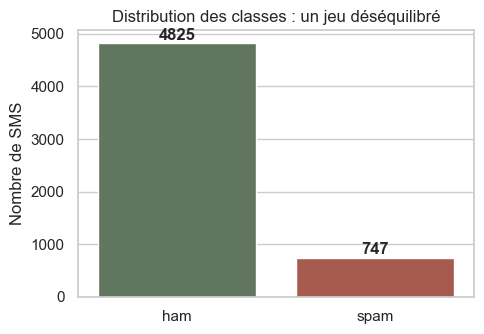

In [3]:
counts = df["label"].value_counts()
share = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({"nombre": counts, "part (%)": share}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(x="label", data=df, hue="label", palette=["#5E7A5A", "#B5503F"], legend=False, ax=ax)
for i, v in enumerate(counts[["ham", "spam"]]):
    ax.text(i, v + 60, f"{v}", ha="center", fontweight="bold")
ax.set_title("Distribution des classes : un jeu déséquilibré")
ax.set_xlabel("")
ax.set_ylabel("Nombre de SMS")
plt.tight_layout()
plt.show()

### 1.4 Longueur des messages

La longueur est déjà un premier **signal** : les spams sont des messages « commerciaux » longs et
denses, les ham sont souvent très courts. Elle nous servira aussi à fixer la longueur maximale
des séquences (padding / troncature).

label             ham   spam
n_chars count  4825.0  747.0
        mean     71.0  138.9
        std      58.0   29.2
        min       2.0   13.0
        25%      33.0  132.5
        50%      52.0  149.0
        75%      92.0  157.0
        max     910.0  224.0
n_words count  4825.0  747.0
        mean     14.2   23.9
        std      11.4    5.8
        min       1.0    2.0
        25%       7.0   22.0
        50%      11.0   25.0
        75%      19.0   28.0
        max     171.0   35.0


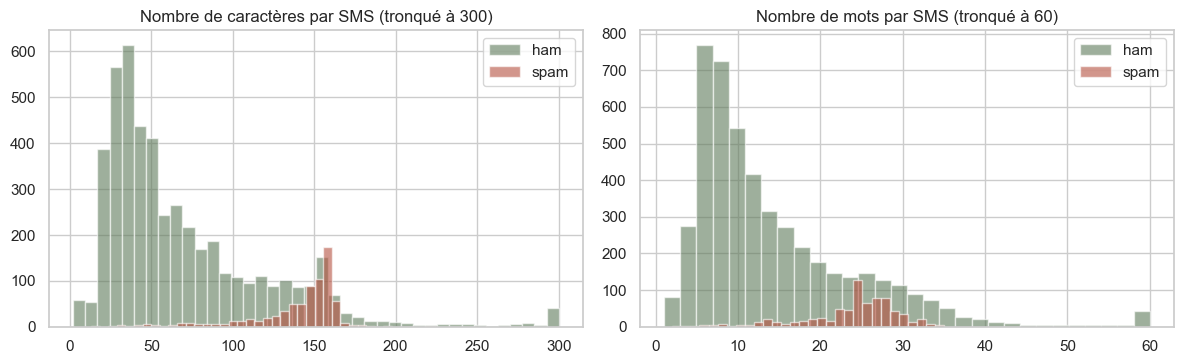

In [4]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(df.groupby("label")[["n_chars", "n_words"]].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for label, color in [("ham", "#5E7A5A"), ("spam", "#B5503F")]:
    subset = df[df["label"] == label]
    axes[0].hist(subset["n_chars"].clip(upper=300), bins=40, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["n_words"].clip(upper=60), bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title("Nombre de caractères par SMS (tronqué à 300)")
axes[1].set_title("Nombre de mots par SMS (tronqué à 60)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Doublons : une source de fuite de données

Le jeu contient des SMS **strictement identiques** (mêmes chaînes de spam envoyées en masse, ou
réponses courtes comme « Ok » ). Si on les laisse, un même message peut se retrouver à la fois dans
le train et dans le test : le modèle serait évalué sur des exemples qu'il a **déjà vus**, et ses
scores seraient artificiellement gonflés. On les supprime **avant** le découpage.

In [5]:
n_dup = df.duplicated(subset=["text", "label"]).sum()
print(f"SMS en doublon exact : {n_dup} ({n_dup / len(df):.1%})")

df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

counts = df["label"].value_counts()
print(f"\nAprès déduplication : {len(df)} SMS "
      f"({counts['ham']} ham / {counts['spam']} spam, "
      f"soit {counts['spam'] / len(df):.1%} de spam)")

SMS en doublon exact : 403 (7.2%)

Après déduplication : 5169 SMS (4516 ham / 653 spam, soit 12.6% de spam)


### 1.6 Quels mots signalent un spam ?

Avant tout modèle, on regarde quels mots sont **quasi exclusifs** à l'une des deux classes (à taille
de classe égale), et à quelle fréquence ils apparaissent. Cela rend lisibles les signaux que les réseaux devront capter, et cela nous servira plus loin
à vérifier ce que la couche d'embedding a réellement appris.

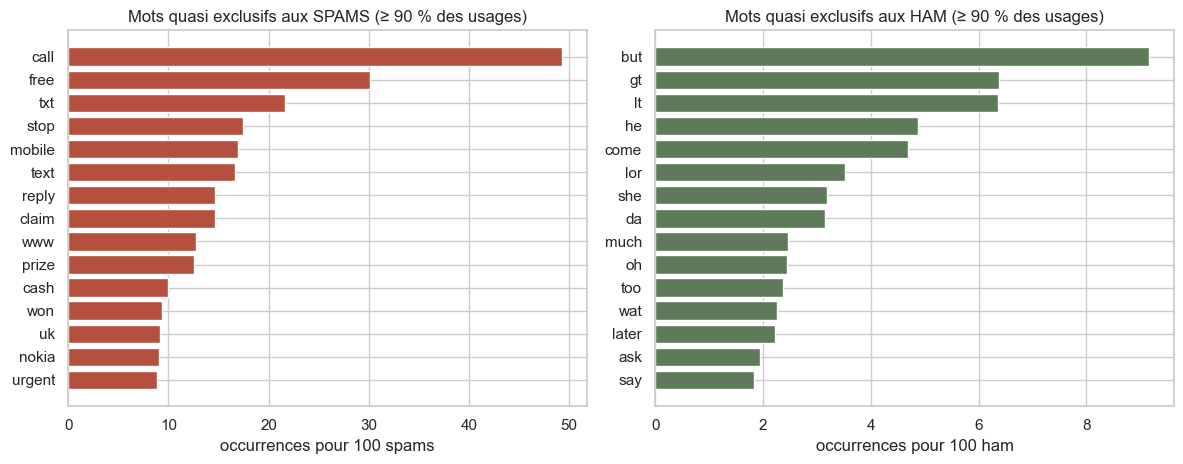

Mots les plus typiques des spams : call, free, txt, stop, mobile, text, reply, claim, www, prize, cash, won, uk, nokia, urgent
Mots les plus typiques des ham   : but, gt, lt, he, come, lor, she, da, much, oh, too, wat, later, ask, say


In [6]:
def simple_tokens(text):
    """Découpe grossière en mots (lettres ASCII uniquement, pour ignorer les résidus d'encodage)."""
    return re.findall(r"[a-z]{2,}", text.lower())


spam_counter = Counter(w for t in df.loc[df.label == "spam", "text"] for w in simple_tokens(t))
ham_counter = Counter(w for t in df.loc[df.label == "ham", "text"] for w in simple_tokens(t))

vocab_stats = pd.DataFrame({
    "spam": pd.Series(spam_counter),
    "ham": pd.Series(ham_counter),
}).fillna(0)
vocab_stats["total"] = vocab_stats["spam"] + vocab_stats["ham"]
# Fréquence pour 100 messages de chaque classe (comparable malgré le déséquilibre)
vocab_stats["spam_per_100"] = vocab_stats["spam"] / counts["spam"] * 100
vocab_stats["ham_per_100"] = vocab_stats["ham"] / counts["ham"] * 100
# Part (lissée) des usages du mot qui viennent d'un spam, à taille de classe égale : 1 = que du spam
vocab_stats["spam_share"] = ((vocab_stats["spam_per_100"] + 0.1)
                             / (vocab_stats["spam_per_100"] + vocab_stats["ham_per_100"] + 0.2))

frequent = vocab_stats[vocab_stats["total"] >= 25]
top_spam = frequent[frequent["spam_share"] >= 0.9].sort_values("spam_per_100", ascending=False).head(15)
top_ham = frequent[frequent["spam_share"] <= 0.1].sort_values("ham_per_100", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].barh(top_spam.index[::-1], top_spam["spam_per_100"][::-1], color="#B5503F")
axes[0].set_title("Mots quasi exclusifs aux SPAMS (≥ 90 % des usages)")
axes[0].set_xlabel("occurrences pour 100 spams")
axes[1].barh(top_ham.index[::-1], top_ham["ham_per_100"][::-1], color="#5E7A5A")
axes[1].set_title("Mots quasi exclusifs aux HAM (≥ 90 % des usages)")
axes[1].set_xlabel("occurrences pour 100 ham")
plt.tight_layout()
plt.show()

print("Mots les plus typiques des spams :", ", ".join(top_spam.index))
print("Mots les plus typiques des ham   :", ", ".join(top_ham.index))

## 2. Découpage train / validation / test

Trois jeux, trois rôles distincts :

| Jeu | Part | Rôle |
|---|---|---|
| **Train** | 72 % | Apprendre les poids du réseau |
| **Validation** | 8 % | Choisir quand arrêter l'entraînement (early stopping), sélectionner la meilleure epoch, régler le seuil de décision |
| **Test** | 20 % | Mesurer **une seule fois, à la fin**, la performance de généralisation |

- Le découpage est **stratifié** : la proportion de spam (≈ 13 %) est conservée dans les trois
  jeux, sinon le test pourrait contenir trop peu de spams pour être fiable.
- Les **mêmes** jeux servent aux deux modèles : la comparaison se fait à données strictement égales.
- Le jeu de test n'est jamais utilisé pour prendre une décision (ni tokenizer, ni seuil, ni
  early stopping) : c'est la garantie contre la **fuite de données**.

In [7]:
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["label_enc"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_df, test_size=0.10, stratify=train_df["label_enc"], random_state=SEED
)

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:<11}: {len(part):>5} SMS | spam = {part['label_enc'].mean():.1%}")

y_train = train_df["label_enc"].values
y_val = val_df["label_enc"].values
y_test = test_df["label_enc"].values

train      :  3721 SMS | spam = 12.6%
validation :   414 SMS | spam = 12.6%
test       :  1034 SMS | spam = 12.7%


## 3. Préparation du texte pour le réseau simple

Un réseau de neurones ne manipule que des nombres. Pour le modèle 1, on construit le
**pipeline NLP** classique en trois étapes :

1. **Nettoyage** : minuscules, suppression des URL, des chiffres et de la ponctuation.
   *Pourquoi ?* Le réseau simple apprend son vocabulaire **uniquement sur nos ~3 700 SMS
   d'entraînement** : chaque variante (« FREE », « Free! », « free… ») compterait comme un mot
   différent et diluerait l'apprentissage. Réduire le bruit concentre l'information.
2. **Tokenisation** : chaque mot reçoit un identifiant entier ; on garde les 10 000 mots les plus
   fréquents, les autres deviennent le jeton `<OOV>` (*out of vocabulary*).
3. **Padding** : toutes les séquences sont ramenées à la même longueur (complétées par des 0 ou
   tronquées), car un réseau exige des entrées de taille fixe.

> **Le tokenizer est ajusté sur le train uniquement.** Le test doit se comporter comme des SMS
> jamais vus : ses mots inconnus deviennent `<OOV>`, exactement comme en production.

In [8]:
def clean_text(text):
    """Nettoyage minimal : minuscules, sans URL, chiffres ni ponctuation."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # URL
    text = re.sub(r"\d+", " ", text)              # chiffres
    text = re.sub(r"[^\w\s]", " ", text)          # ponctuation
    text = re.sub(r"\s+", " ", text).strip()
    # Un SMS fait uniquement de chiffres / ponctuation devient vide : on lui donne un jeton
    # explicite, sinon sa séquence ne contiendrait que du padding (moyenne indéfinie).
    return text if text else "emptysms"


X_train_txt = train_df["text"].apply(clean_text)
X_val_txt = val_df["text"].apply(clean_text)
X_test_txt = test_df["text"].apply(clean_text)

print(f"SMS vides après nettoyage (train) : {(X_train_txt == 'emptysms').sum()}")
example = train_df["text"].iloc[3]
print("SMS original   :", example)
print("Après nettoyage:", clean_text(example))

SMS vides après nettoyage (train) : 2
SMS original   : Leave it. U will always be ignorant.
Après nettoyage: leave it u will always be ignorant


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10_000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_txt)          # ajusté sur le TRAIN uniquement

X_train_seq = tokenizer.texts_to_sequences(X_train_txt)
X_val_seq = tokenizer.texts_to_sequences(X_val_txt)
X_test_seq = tokenizer.texts_to_sequences(X_test_txt)

seq_lengths = np.array([len(s) for s in X_train_seq])
print(f"Mots distincts dans le train : {len(tokenizer.word_index)}")
print(f"Longueur des séquences (train) : médiane = {np.median(seq_lengths):.0f}, "
      f"95e pct = {np.percentile(seq_lengths, 95):.0f}, "
      f"99e pct = {np.percentile(seq_lengths, 99):.0f}, max = {seq_lengths.max()}")

Mots distincts dans le train : 6405
Longueur des séquences (train) : médiane = 12, 95e pct = 33, 99e pct = 51, max = 117


**Choix de la longueur maximale.** 99 % des SMS font moins de ~55 jetons : on fixe `MAX_LEN = 64`.
Une valeur plus grande n'ajouterait presque que des zéros (calcul inutile) ; une valeur plus petite
tronquerait la fin de certains spams longs, or c'est souvent là que se trouvent le numéro à
appeler ou le lien.

In [10]:
MAX_LEN = 64

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Shape train : {X_train_pad.shape} | val : {X_val_pad.shape} | test : {X_test_pad.shape}")
print(f"\nTroncature : {(seq_lengths > MAX_LEN).mean():.2%} des SMS du train dépassent {MAX_LEN} jetons")
print("\nExemple de tenseur d'entrée (20 premières positions) :")
print(X_train_pad[3][:20])

Shape train : (3721, 64) | val : (414, 64) | test : (1034, 64)

Troncature : 0.51% des SMS du train dépassent 64 jetons

Exemple de tenseur d'entrée (20 premières positions) :
[ 236   14    7   35  245   36 2985    0    0    0    0    0    0    0
    0    0    0    0    0    0]


## 4. Modèle 1 : Embedding + réseau dense (baseline)

### 4.1 Architecture et justification de chaque couche

| Couche | Rôle | Pourquoi ce choix |
|---|---|---|
| `Embedding(10 000 mots, 32 dimensions)` | Remplace chaque identifiant de mot par un **vecteur dense de 32 nombres**, appris pendant l'entraînement. Deux mots utilisés dans des contextes similaires se retrouvent proches dans cet espace. | Un identifiant entier n'a aucun sens (« free » = 45 et « win » = 302 ne sont pas « proches »). L'embedding transforme l'identité du mot en **représentation porteuse de sens**. 32 dimensions suffisent pour un vocabulaire de 10 000 mots et ~3 700 exemples : plus large, le modèle sur-apprendrait. |
| `GlobalAveragePooling1D` (avec masque) | Fait la **moyenne des vecteurs** des mots du SMS pour obtenir un seul vecteur de 32 nombres qui résume le message. Le masque ignore les zéros de padding. | Simple, rapide, insensible à la longueur du message. Pour du spam, la **présence** de mots (« free », « prize », « claim ») compte plus que leur ordre ; un réseau récurrent (LSTM) ou convolutif serait plus lourd pour un gain incertain sur des messages aussi courts. |
| `Dense(64, ReLU)` | Combine les 32 dimensions pour créer des motifs non linéaires. | ReLU : simple, évite la saturation des gradients. |
| `Dropout(0.3)` | Éteint 30 % des neurones à chaque passage d'entraînement. | Régularisation : empêche le réseau de mémoriser les SMS du train (petit jeu de données, donc risque élevé de sur-apprentissage). |
| `Dense(1, sigmoïde)` | Sort une **probabilité de spam** entre 0 et 1. | Classification binaire, donc un seul neurone et une sigmoïde. |

### 4.2 Fonction de coût et gestion du déséquilibre

- **Fonction de coût : entropie croisée binaire** (*binary cross-entropy*) :
  $\mathcal{L} = -\frac{1}{N}\sum_i \left[y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\right]$.
  Elle mesure l'écart entre la probabilité prédite $\hat p_i$ et la vraie classe $y_i$, et pénalise
  très fortement une prédiction confiante mais fausse. C'est la fonction adaptée à une sortie
  sigmoïde (la *mean squared error* donnerait des gradients faibles quand la sigmoïde sature).
- **Pondération des classes** : chaque erreur sur un spam pèse ~6,5 fois plus qu'une erreur sur un
  ham (rapport ham/spam du train). Sans cela le réseau minimise sa perte en privilégiant la classe
  majoritaire.
- **Optimiseur Adam** (taux d'apprentissage par défaut 1e-3) : adaptatif, robuste, standard pour
  un petit réseau entraîné de zéro.
- **Early stopping** sur la perte de validation : on arrête dès que le modèle ne progresse plus sur
  des données qu'il n'apprend pas, et on restaure les meilleurs poids. Cela évite le
  sur-apprentissage et rend le nombre d'epochs un choix **mesuré**, pas arbitraire.

In [11]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 32

# Pondération des classes : une erreur sur un spam pèse (n_ham / n_spam) fois plus
n_spam = y_train.sum()
n_ham = len(y_train) - n_spam
class_weight = {0: 1.0, 1: n_ham / n_spam}
print(f"Poids appliqué à la classe spam : {class_weight[1]:.2f}")

model1 = Sequential([
    Input(shape=(MAX_LEN,), name="tokens"),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name="embedding"),
    GlobalAveragePooling1D(name="moyenne_des_mots"),
    Dense(64, activation="relu", name="dense_64"),
    Dropout(0.3, name="dropout"),
    Dense(1, activation="sigmoid", name="proba_spam"),
], name="modele1_embedding_dense")

model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)
model1.summary()

Poids appliqué à la classe spam : 6.92


Model: "modele1_embedding_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ moyenne_des_mots                │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proba_spam (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,177 (1.23 MB)

 Trainable params: 322,177 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1)

t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=2,
)
train_time_1 = time.time() - t0
best_epoch_1 = int(np.argmin(history1.history["val_loss"])) + 1
print(f"\nTemps d'entraînement : {train_time_1:.1f} s | epochs exécutées : "
      f"{len(history1.history['loss'])} | meilleure epoch (val_loss) : {best_epoch_1}")

Epoch 1/30


117/117 - 1s - 6ms/step - accuracy: 0.9129 - loss: 0.9902 - precision: 0.6177 - recall: 0.8149 - val_accuracy: 0.9686 - val_loss: 0.2798 - val_precision: 0.8545 - val_recall: 0.9038


Epoch 2/30


117/117 - 0s - 859us/step - accuracy: 0.9680 - loss: 0.2934 - precision: 0.8185 - recall: 0.9596 - val_accuracy: 0.9686 - val_loss: 0.1218 - val_precision: 0.8545 - val_recall: 0.9038


Epoch 3/30


...

Epoch 8/30


117/117 - 0s - 829us/step - accuracy: 0.9995 - loss: 0.0083 - precision: 0.9958 - recall: 1.0000 - val_accuracy: 0.9758 - val_loss: 0.1115 - val_precision: 0.8889 - val_recall: 0.9231


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 4.



Temps d'entraînement : 1.4 s | epochs exécutées : 8 | meilleure epoch (val_loss) : 4


### 4.3 Courbes d'apprentissage

On vérifie qu'il n'y a pas de sur-apprentissage : les courbes train et validation doivent rester
proches. La perte de validation qui remonte signalerait que le modèle commence à mémoriser le train.

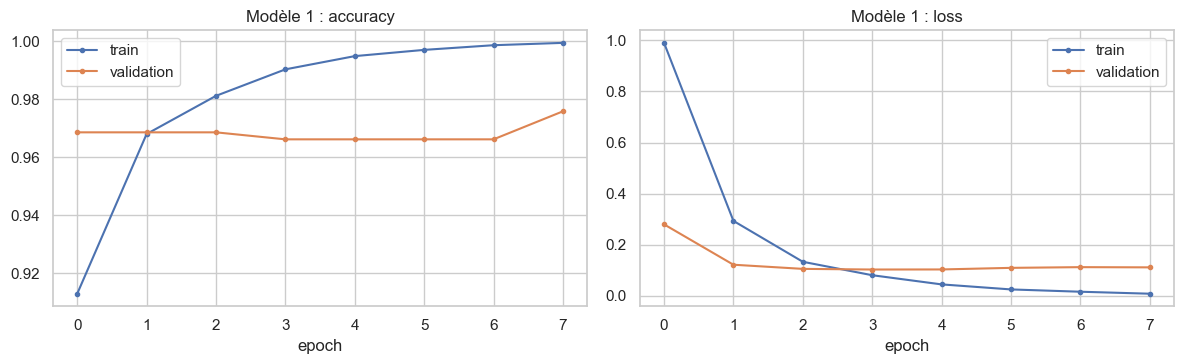

In [13]:
def plot_history(history, title):
    """Trace accuracy et perte (train vs validation) au fil des epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(history.history[metric], label="train", marker="o", ms=3)
        ax.plot(history.history[f"val_{metric}"], label="validation", marker="o", ms=3)
        ax.set_title(f"{title} : {metric}")
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_history(history1, "Modèle 1")

### 4.4 Évaluation sur le jeu de test

On utilise ici le jeu de test pour la **première fois**. Le seuil de décision est le seuil par
défaut de 0,5 (il sera discuté en section 8). On lit surtout :

- la **matrice de confusion** : combien de spams attrapés (vrais positifs), combien de spams passés
  au travers (faux négatifs), combien de messages légitimes bloqués à tort (faux positifs) ;
- le **F1 spam**, notre métrique de référence.

=== Modèle 1 : Embedding + Dense (seuil = 0.50) ===
              precision    recall  f1-score   support

         ham      0.992     0.984     0.988       903
        spam      0.899     0.947     0.922       131

    accuracy                          0.980      1034
   macro avg      0.945     0.966     0.955      1034
weighted avg      0.980     0.980     0.980      1034



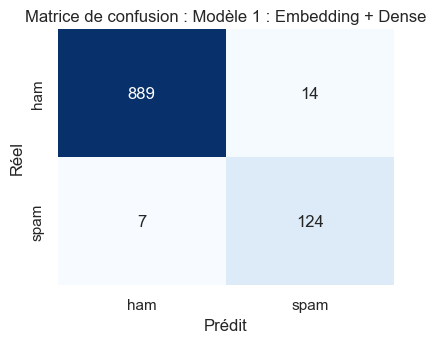

In [14]:
results = []


def evaluate_model(name, y_true, y_prob, threshold=0.5, cmap="Blues",
                   train_time=None, n_params=None, hardware=None):
    """Affiche le rapport de classification + matrice de confusion et mémorise les métriques."""
    y_pred = (y_prob >= threshold).astype(int)
    print(f"=== {name} (seuil = {threshold:.2f}) ===")
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"], digits=3))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False,
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=ax)
    ax.set_title(f"Matrice de confusion : {name}")
    ax.set_ylabel("Réel")
    ax.set_xlabel("Prédit")
    plt.tight_layout()
    plt.show()

    metrics = {
        "modèle": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "précision spam": precision_score(y_true, y_pred),
        "rappel spam": recall_score(y_true, y_pred),
        "F1 spam": f1_score(y_true, y_pred),
        "spams attrapés (TP)": int(tp),
        "spams manqués (FN)": int(fn),
        "ham bloqués (FP)": int(fp),
        "paramètres": n_params,
        "temps entraînement (s)": None if train_time is None else round(train_time, 1),
        "matériel": hardware,
    }
    results.append(metrics)
    return metrics


y_prob1_test = model1.predict(X_test_pad, verbose=0).ravel()
y_prob1_val = model1.predict(X_val_pad, verbose=0).ravel()

metrics1 = evaluate_model(
    "Modèle 1 : Embedding + Dense", y_test, y_prob1_test, cmap="Blues",
    train_time=train_time_1, n_params=model1.count_params(), hardware="CPU",
)

Le réseau simple atteint déjà un **F1 spam de 0,922**. Grâce à la pondération de
classe, son **rappel est élevé (0,947 : 124 spams sur 131 attrapés)**, mais sa **précision est
plus faible (0,899)** : il bloque **14 messages légitimes sur 903**. Il « sur-alerte » : dès qu'un
message contient du vocabulaire commercial, il le classe spam. C'est exactement le type d'erreur
le plus coûteux pour AT&T, et c'est ce que le modèle 2 devra corriger.

## 5. Ce qu'a appris la couche d'embedding

La couche `Embedding` est une matrice de **10 000 lignes × 32 colonnes** : une ligne par mot du
vocabulaire, apprise uniquement à partir de l'objectif « ham ou spam ». Au départ ces vecteurs sont
aléatoires ; à la fin de l'entraînement, deux mots qui jouent le même rôle dans la décision doivent
être **géométriquement proches**. On le vérifie de deux façons :

1. **Plus proches voisins** (similarité cosinus) de quelques mots-clés.
2. **Projection en 2D** (PCA) des mots les plus fréquents, colorés selon leur taux de spam.

C'est l'intuition fondamentale de l'embedding : *remplacer un identifiant arbitraire par une
position dans un espace où la distance a un sens*.

In [15]:
from sklearn.decomposition import PCA

embedding_matrix = model1.get_layer("embedding").get_weights()[0]      # (VOCAB_SIZE, 32)
index_word = {i: w for w, i in tokenizer.word_index.items() if i < VOCAB_SIZE}
word_index = {w: i for i, w in index_word.items()}

# Normalisation pour une similarité cosinus
norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True) + 1e-9
emb_unit = embedding_matrix / norms


def nearest_words(word, k=6):
    """Retourne les k mots dont l'embedding est le plus proche (cosinus) de `word`."""
    if word not in word_index:
        return f"« {word} » absent du vocabulaire"
    idx = word_index[word]
    sims = emb_unit @ emb_unit[idx]
    sims[idx] = -1                       # on exclut le mot lui-même
    sims[:2] = -1                        # on exclut padding et <OOV>
    top = np.argsort(-sims)[:k]
    return ", ".join(f"{index_word[i]} ({sims[i]:.2f})" for i in top if i in index_word)


print(f"Matrice d'embedding : {embedding_matrix.shape}\n")
for w in ["free", "win", "prize", "claim", "txt", "urgent", "call", "ok", "love", "home", "sorry"]:
    print(f"{w:>8} : {nearest_words(w)}")

Matrice d'embedding : (10000, 32)

    free : call (0.96), from (0.93), ppm (0.93), new (0.93), rental (0.93), guaranteed (0.93)
     win : stop (0.96), txt (0.96), uk (0.95), tone (0.95), å (0.95), mobile (0.94)
   prize : urgent (0.97), txt (0.97), å (0.96), mobile (0.96), cs (0.96), stop (0.95)
   claim : å (0.96), mobile (0.96), tone (0.96), txt (0.96), service (0.96), p (0.96)
     txt : å (0.99), stop (0.98), p (0.97), mobile (0.97), text (0.97), prize (0.97)
  urgent : prize (0.97), claim (0.95), mobile (0.95), txt (0.95), å (0.95), p (0.95)
    call : free (0.96), from (0.95), our (0.92), or (0.92), guaranteed (0.92), contact (0.91)
      ok : going (0.96), she (0.96), gt (0.96), said (0.96), sorry (0.96), still (0.96)
    love : b (0.65), of (0.64), on (0.63), vegetables (0.62), you (0.61)
    home : she (0.97), he (0.97), its (0.97), said (0.97), got (0.97), haf (0.97)
   sorry : k (0.97), still (0.97), gt (0.96), said (0.96), boy (0.96), y (0.96)


Les voisinages sont cohérents avec l'analyse de la section 1.6 :

- Les mots du **champ lexical du spam** se regroupent : `prize` est proche de `urgent`, `txt`, `mobile`,
  `stop` ; `win` de `txt`, `tone`, `mobile` ; `free` de `call`, `guaranteed`, `new`.
- Les mots du **quotidien** forment un autre groupe : `ok` est proche de `going`, `said`, `sorry`, `still` ;
  `home` de `she`, `he`, `got`.
- Le jeton `å` qui apparaît parmi les voisins des mots de spam est un **résidu d'encodage du
  symbole £** (le fichier est en latin-1) : les montants d'argent sont un signal de spam très fort,
  et le modèle l'a appris tout seul.

Le modèle n'a jamais reçu de dictionnaire : ces proximités émergent uniquement de l'objectif
« ham ou spam ». C'est ce que signifie *apprendre une représentation*.

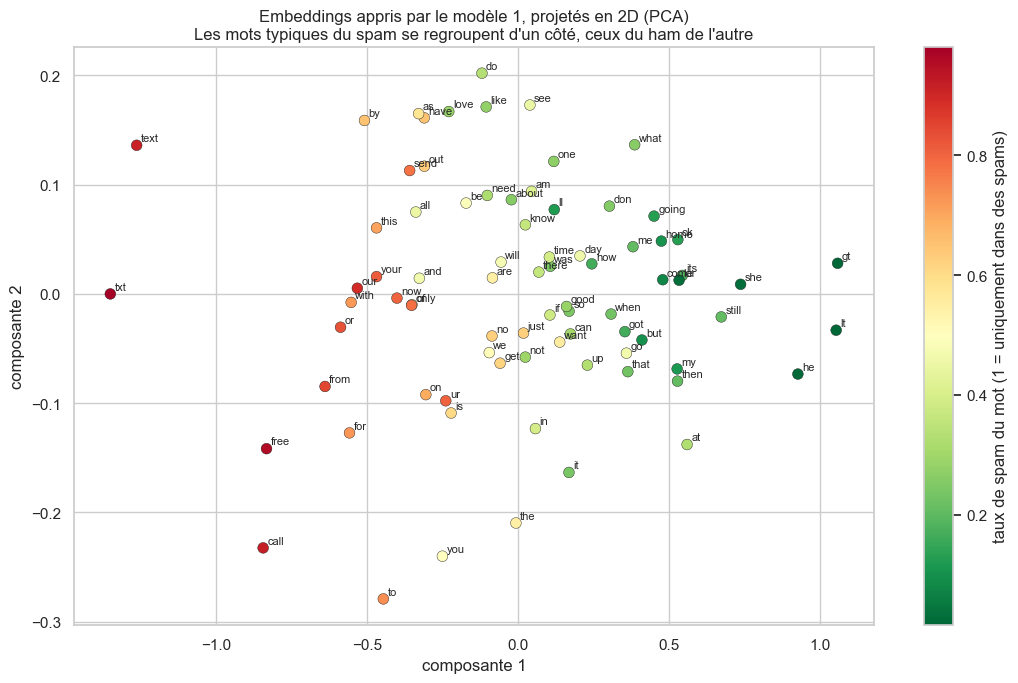

In [16]:
# Projection 2D des ~80 mots les plus fréquents, colorés par « taux de spam » observé (section 1.6)
top_words = [index_word[i] for i in range(2, 200) if i in index_word]
top_words = [w for w in top_words if w in vocab_stats.index][:80]
coords = PCA(n_components=2, random_state=SEED).fit_transform(
    embedding_matrix[[word_index[w] for w in top_words]]
)
colors = vocab_stats.loc[top_words, "spam_share"].values

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap="RdYlGn_r", s=60, edgecolor="k", lw=0.3)
for (x, y), w in zip(coords, top_words):
    ax.annotate(w, (x, y), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, label="taux de spam du mot (1 = uniquement dans des spams)")
ax.set_title("Embeddings appris par le modèle 1, projetés en 2D (PCA)\n"
             "Les mots typiques du spam se regroupent d'un côté, ceux du ham de l'autre")
ax.set_xlabel("composante 1")
ax.set_ylabel("composante 2")
plt.tight_layout()
plt.show()

## 6. Modèle 2 : DistilBERT, transfer learning et fine-tuning

### 6.1 Pourquoi un modèle pré-entraîné ?

Le modèle 1 doit apprendre **la langue et la tâche en même temps**, à partir de ~3 700 SMS. C'est
peu : il ne peut apprendre que des associations du type « ce mot implique spam ».

**DistilBERT** (HuggingFace, `distilbert-base-uncased`) est un **Transformer** déjà pré-entraîné sur
des milliards de mots (Wikipédia + livres) à deviner des mots masqués. Il arrive donc avec une
connaissance générale de l'anglais : vocabulaire, grammaire, et surtout des **embeddings
contextuels** : le vecteur de « free » n'est pas le même dans « free entry » et dans « feel free »,
grâce au **mécanisme d'attention** qui pondère, pour chaque mot, les autres mots de la phrase.

**Fine-tuning** : on ajoute une petite tête de classification (2 sorties : ham / spam) au-dessus du
modèle pré-entraîné et on **continue l'entraînement de l'ensemble** sur nos SMS, avec un taux
d'apprentissage très faible (2e-5) pour **ajuster** les connaissances sans les effacer. C'est le
principe du **transfer learning** : réutiliser ce qui a été appris sur une tâche générale pour une
tâche spécifique avec peu de données.

| | BERT-base | DistilBERT |
|---|---|---|
| Paramètres | 110 M | 66 M (−40 %) |
| Vitesse | 1× | ~1,6× plus rapide |
| Performance conservée | 100 % | ~97 % |

DistilBERT est obtenu par **distillation** : un petit modèle « élève » apprend à imiter les sorties
du grand modèle « professeur ». On garde l'essentiel de la performance pour un coût nettement plus
faible, un bon compromis pour un service qui doit traiter des millions de SMS.

### 6.2 Prétraitement : pourquoi on ne nettoie PAS le texte ici

DistilBERT possède son **propre tokenizer WordPiece**, appris avec lui : il gère les majuscules
(version *uncased*), découpe les mots inconnus en sous-mots (« txting » devient « txt » + « ##ing ») et
sait exploiter la ponctuation et les chiffres. On lui donne donc le **texte brut** : « £1000 »,
« !!! » ou « 08001234567 » sont des signaux de spam qu'un nettoyage agressif aurait détruits.
On applique les mêmes principes que pour le modèle 1 : découpage identique, padding à longueur
fixe, troncature au-delà.

In [17]:
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup, logging as hf_logging)
from torch.utils.data import DataLoader, TensorDataset

hf_logging.set_verbosity_error()
MODEL_NAME = "distilbert-base-uncased"
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Combien de jetons WordPiece font nos SMS bruts ? (pour choisir la longueur max)
bert_lengths = np.array([len(ids) for ids in bert_tokenizer(list(train_df["text"]))["input_ids"]])
print(f"Jetons WordPiece par SMS (train) : médiane = {np.median(bert_lengths):.0f}, "
      f"95e pct = {np.percentile(bert_lengths, 95):.0f}, "
      f"99e pct = {np.percentile(bert_lengths, 99):.0f}, max = {bert_lengths.max()}")

print("\nExemple de tokenisation WordPiece :")
sample = train_df.loc[train_df.label == "spam", "text"].iloc[0]
print(sample)
print(bert_tokenizer.tokenize(sample)[:30])

Jetons WordPiece par SMS (train) : médiane = 19, 95e pct = 54, 99e pct = 72, max = 238

Exemple de tokenisation WordPiece :
Hi. Customer Loyalty Offer:The NEW Nokia6650 Mobile from ONLY å£10 at TXTAUCTION! Txt word: START to No: 81151 & get yours Now! 4T&Ctxt TC 150p/MTmsg
['hi', '.', 'customer', 'loyalty', 'offer', ':', 'the', 'new', 'nokia', '##66', '##50', 'mobile', 'from', 'only', 'a', '##£', '##10', 'at', 'tx', '##ta', '##uc', '##tion', '!', 'tx', '##t', 'word', ':', 'start', 'to', 'no']


In [18]:
BERT_MAX_LEN = 96
print(f"Troncature : {(bert_lengths > BERT_MAX_LEN).mean():.2%} des SMS du train dépassent {BERT_MAX_LEN} jetons")


def encode(texts):
    """Texte brut vers tenseurs (input_ids, attention_mask) de longueur fixe."""
    return bert_tokenizer(list(texts), max_length=BERT_MAX_LEN, padding="max_length",
                          truncation=True, return_tensors="pt")


def make_loader(texts, labels, shuffle):
    enc = encode(texts)
    dataset = TensorDataset(enc["input_ids"], enc["attention_mask"],
                            torch.tensor(labels, dtype=torch.long))
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(dataset, batch_size=32, shuffle=shuffle, generator=generator)


train_loader = make_loader(train_df["text"], y_train, shuffle=True)
val_loader = make_loader(val_df["text"], y_val, shuffle=False)
test_loader = make_loader(test_df["text"], y_test, shuffle=False)

print(f"Batchs : train = {len(train_loader)}, val = {len(val_loader)}, test = {len(test_loader)}")
print(f"Forme d'un batch d'input_ids : {next(iter(train_loader))[0].shape}  (batch, jetons)")

Troncature : 0.38% des SMS du train dépassent 96 jetons


Batchs : train = 117, val = 13, test = 33
Forme d'un batch d'input_ids : torch.Size([32, 96])  (batch, jetons)


### 6.3 Fine-tuning

Choix d'entraînement et raisons :

- **Fonction de coût : entropie croisée** (`CrossEntropyLoss`) sur 2 logits. C'est la
  généralisation à $K$ classes de l'entropie croisée binaire du modèle 1 (avec $K = 2$, softmax sur
  deux logits ≡ sigmoïde sur leur différence). Même objectif, formulé comme HuggingFace l'attend.
- **Optimiseur AdamW**, taux d'apprentissage **2e-5** : 50 fois plus petit que pour le modèle 1.
  Les poids pré-entraînés sont déjà bons ; de grands pas les détruiraient (*catastrophic
  forgetting*). AdamW ajoute une régularisation (*weight decay*) découplée, standard pour les
  Transformers.
- **Scheduler linéaire avec warm-up** (10 % des pas) : le taux d'apprentissage monte doucement puis
  décroît, ce qui stabilise les premiers pas où la tête de classification est encore aléatoire.
- **3 epochs** maximum, et on garde les poids de l'epoch qui a le **meilleur F1 spam sur la
  validation**, l'équivalent de l'early stopping du modèle 1. Avec 66 M de paramètres pour
  ~3 700 exemples, plus d'epochs ne feraient que sur-apprendre.
- **Pas de pondération de classe** ici : le modèle pré-entraîné distingue déjà bien les deux
  classes ; on préfère garder des probabilités bien calibrées et régler le compromis
  précision / rappel par le **seuil de décision** (section 8).

In [19]:
model2 = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
n_params_2 = sum(p.numel() for p in model2.parameters())
print(f"DistilBERT : {n_params_2 / 1e6:.1f} M de paramètres (contre {model1.count_params() / 1e6:.2f} M "
      f"pour le modèle 1)")

EPOCHS = 3
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model2.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)


def predict_proba(model, loader):
    """Probabilité de spam (softmax sur les 2 logits) pour chaque SMS du loader."""
    model.eval()
    probs = []
    with torch.no_grad():
        for input_ids, attention_mask, _ in loader:
            logits = model(input_ids=input_ids.to(DEVICE),
                           attention_mask=attention_mask.to(DEVICE)).logits
            probs.append(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
    return np.concatenate(probs)


def eval_loss(model, loader):
    """Perte moyenne (entropie croisée) sur un loader, sans mise à jour des poids."""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            logits = model(input_ids=input_ids.to(DEVICE),
                           attention_mask=attention_mask.to(DEVICE)).logits
            total += loss_fn(logits, labels.to(DEVICE)).item()
    return total / len(loader)


history2 = {"loss": [], "val_loss": [], "val_f1": []}
best_state, best_f1, best_epoch_2 = None, -1.0, 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model2.train()
    running = 0.0
    for input_ids, attention_mask, labels in train_loader:
        optimizer.zero_grad()
        logits = model2(input_ids=input_ids.to(DEVICE),
                        attention_mask=attention_mask.to(DEVICE)).logits
        loss = loss_fn(logits, labels.to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)   # stabilise le fine-tuning
        optimizer.step()
        scheduler.step()
        running += loss.item()

    train_loss = running / len(train_loader)
    val_loss = eval_loss(model2, val_loader)
    val_f1 = f1_score(y_val, (predict_proba(model2, val_loader) >= 0.5).astype(int))
    history2["loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["val_f1"].append(val_f1)
    print(f"Epoch {epoch}/{EPOCHS} | loss train : {train_loss:.4f} | loss val : {val_loss:.4f} "
          f"| F1 spam val : {val_f1:.4f} | {time.time() - t0:.0f} s")

    if val_f1 > best_f1:
        best_f1, best_epoch_2 = val_f1, epoch
        best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model2.state_dict().items()})

train_time_2 = time.time() - t0
model2.load_state_dict(best_state)
model2.to(DEVICE)
print(f"\nTemps de fine-tuning : {train_time_2 / 60:.1f} min | poids retenus : epoch {best_epoch_2} "
      f"(F1 spam validation = {best_f1:.4f})")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT : 67.0 M de paramètres (contre 0.32 M pour le modèle 1)


Epoch 1/3 | loss train : 0.1987 | loss val : 0.0274 | F1 spam val : 0.9615 | 63 s


Epoch 2/3 | loss train : 0.0318 | loss val : 0.0296 | F1 spam val : 0.9615 | 124 s


Epoch 3/3 | loss train : 0.0216 | loss val : 0.0240 | F1 spam val : 0.9709 | 184 s

Temps de fine-tuning : 3.1 min | poids retenus : epoch 3 (F1 spam validation = 0.9709)


Dès la **première epoch**, la perte de validation tombe à 0,027 et le F1 spam de
validation à 0,96 : le modèle pré-entraîné « comprend » la tâche presque immédiatement, c'est
l'effet du transfer learning. Les epochs 2 et 3 affinent légèrement (F1 val 0,971). Au-delà, la
perte d'entraînement continue de baisser alors que la perte de validation stagne : on
sur-apprendrait. Trois epochs sont donc le bon compromis, et le fine-tuning complet prend
~3 minutes sur une puce Apple Silicon (environ 1 minute sur un GPU T4 de Colab).

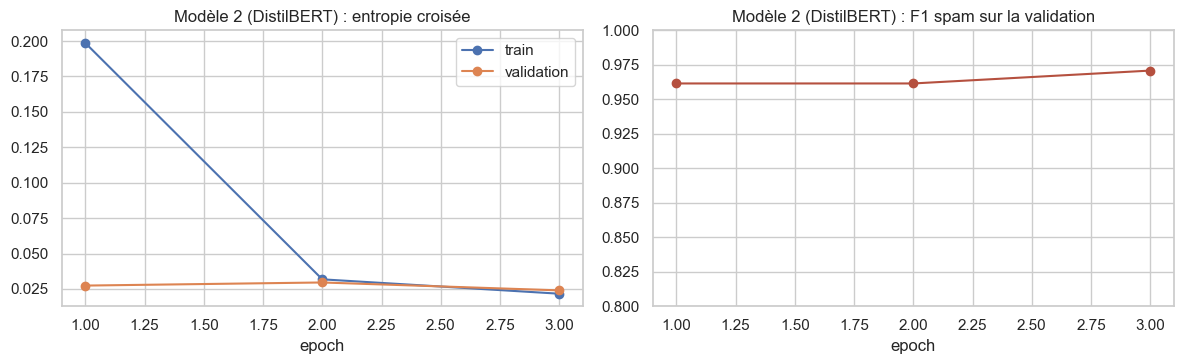

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
epochs_axis = range(1, len(history2["loss"]) + 1)
axes[0].plot(epochs_axis, history2["loss"], marker="o", label="train")
axes[0].plot(epochs_axis, history2["val_loss"], marker="o", label="validation")
axes[0].set_title("Modèle 2 (DistilBERT) : entropie croisée")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(epochs_axis, history2["val_f1"], marker="o", color="#B5503F")
axes[1].set_title("Modèle 2 (DistilBERT) : F1 spam sur la validation")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

### 6.4 Évaluation sur le jeu de test

=== Modèle 2 : DistilBERT fine-tuné (seuil = 0.50) ===
              precision    recall  f1-score   support

         ham      0.992     0.999     0.996       903
        spam      0.992     0.947     0.969       131

    accuracy                          0.992      1034
   macro avg      0.992     0.973     0.982      1034
weighted avg      0.992     0.992     0.992      1034



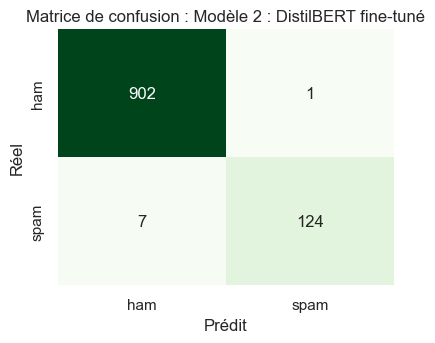

In [21]:
hardware_2 = {"cuda": "GPU " + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else ""),
              "mps": "Apple Silicon (MPS)", "cpu": "CPU"}[DEVICE.type]

y_prob2_test = predict_proba(model2, test_loader)
y_prob2_val = predict_proba(model2, val_loader)

metrics2 = evaluate_model(
    "Modèle 2 : DistilBERT fine-tuné", y_test, y_prob2_test, cmap="Greens",
    train_time=train_time_2, n_params=n_params_2, hardware=hardware_2,
)

DistilBERT obtient un **F1 spam de 0,969**. Son **rappel est identique** au réseau
simple (0,947 : mêmes 7 spams manqués sur 131), mais sa **précision passe de 0,899 à 0,992** :
**1 seul message légitime bloqué sur 903**, contre 14. Le modèle pré-entraîné distingue un vrai
spam d'un message légitime qui emploie du vocabulaire commercial (facture, commande, rendez-vous),
parce qu'il comprend le **contexte** de la phrase et pas seulement la présence de certains mots.

## 7. Comparaison des deux modèles

Les deux modèles ont été entraînés et évalués sur **exactement les mêmes SMS**, avec le même seuil
(0,5). La comparaison porte sur la performance (F1, précision, rappel) **et** sur le coût
(paramètres, temps, matériel) : en production, les deux comptent.

In [22]:
comparison = pd.DataFrame(results).set_index("modèle")
display_cols = ["accuracy", "précision spam", "rappel spam", "F1 spam",
                "spams attrapés (TP)", "spams manqués (FN)", "ham bloqués (FP)",
                "paramètres", "temps entraînement (s)", "matériel"]
styled = comparison[display_cols].copy()
for c in ["accuracy", "précision spam", "rappel spam", "F1 spam"]:
    styled[c] = styled[c].map(lambda v: f"{v:.3f}")
styled["paramètres"] = styled["paramètres"].map(lambda v: f"{v / 1e6:.2f} M")
print(styled.T.to_string())

gain_f1 = comparison.loc[metrics2["modèle"], "F1 spam"] - comparison.loc[metrics1["modèle"], "F1 spam"]
gain_tp = metrics2["spams attrapés (TP)"] - metrics1["spams attrapés (TP)"]
print(f"\nGain DistilBERT vs baseline : F1 spam {gain_f1:+.3f} | spams attrapés en plus : {gain_tp:+d} "
      f"| faux positifs : de {metrics1['ham bloqués (FP)']} à {metrics2['ham bloqués (FP)']}")

modèle                 Modèle 1 : Embedding + Dense Modèle 2 : DistilBERT fine-tuné
accuracy                                      0.980                           0.992
précision spam                                0.899                           0.992
rappel spam                                   0.947                           0.947
F1 spam                                       0.922                           0.969
spams attrapés (TP)                             124                             124
spams manqués (FN)                                7                               7
ham bloqués (FP)                                 14                               1
paramètres                                   0.32 M                         66.96 M
temps entraînement (s)                          1.4                           184.0
matériel                                        CPU             Apple Silicon (MPS)

Gain DistilBERT vs baseline : F1 spam +0.047 | spams attrapés en plus : +0 

Le gain de DistilBERT (**+0,047 de F1 spam**) vient entièrement de la
**précision** : à rappel égal, il divise par 14 le nombre de messages légitimes bloqués à tort.
C'est le compromis qui compte pour AT&T. Le coût est réel : **200 fois plus de paramètres** et un
entraînement **100 fois plus long**, qui nécessite un accélérateur (GPU ou Apple Silicon). Le
réseau simple reste une baseline honnête, utilisable là où les ressources sont très contraintes.

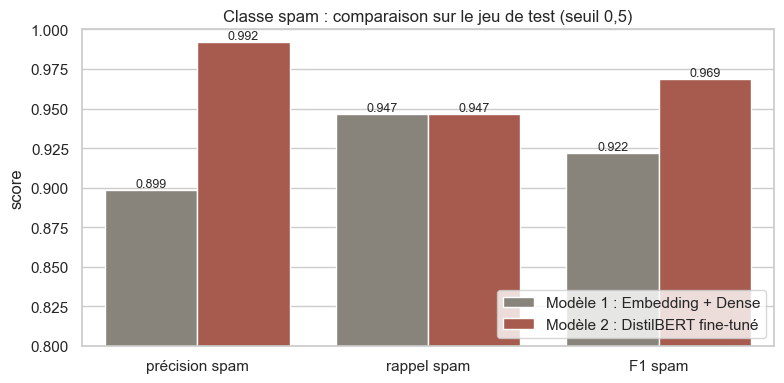

In [23]:
metrics_to_plot = ["précision spam", "rappel spam", "F1 spam"]
plot_df = comparison[metrics_to_plot].reset_index().melt(id_vars="modèle", var_name="métrique",
                                                          value_name="score")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x="métrique", y="score", hue="modèle",
            palette=["#8A847A", "#B5503F"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)
ax.set_ylim(0.8, 1.0)
ax.set_title("Classe spam : comparaison sur le jeu de test (seuil 0,5)")
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Choix du seuil de décision : le point de vue métier

Les deux modèles produisent une **probabilité** de spam ; c'est le **seuil** qui la transforme en
décision. Le seuil 0,5 est un défaut, pas une vérité métier. Pour AT&T les deux erreurs n'ont pas le
même coût :

- **Faux positif** (vrai message bloqué) : le client ne reçoit pas un SMS important (code bancaire,
  rendez-vous). C'est perçu comme une panne du service, donc le coût est élevé.
- **Faux négatif** (spam qui passe) : nuisance, risque d'arnaque, mais le client reste maître.

On explore donc le compromis **précision / rappel** en faisant varier le seuil, **sur le jeu de
validation** et jamais sur le test, puis on retient un seuil qui garantit une précision très élevée
(≥ 98 %) et on observe le rappel obtenu sur le test.

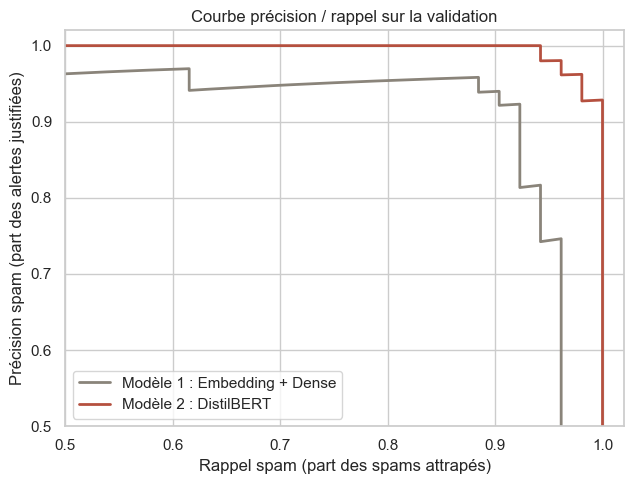

Seuil garantissant ≥ 98 % de précision sur la validation, puis effet sur le TEST :

                       seuil  précision test  rappel test  F1 test  ham bloqués (FP)  spams manqués (FN)
modèle                                                                                                  
Modèle 1               0.998           0.972        0.267    0.419                 1                  96
Modèle 2 (DistilBERT)  0.598           0.992        0.947    0.969                 1                   7


In [24]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, y_prob_val, color in [("Modèle 1 : Embedding + Dense", y_prob1_val, "#8A847A"),
                                ("Modèle 2 : DistilBERT", y_prob2_val, "#B5503F")]:
    precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
    ax.plot(recall, precision, label=name, color=color, lw=2)
ax.set_xlabel("Rappel spam (part des spams attrapés)")
ax.set_ylabel("Précision spam (part des alertes justifiées)")
ax.set_title("Courbe précision / rappel sur la validation")
ax.set_xlim(0.5, 1.02)
ax.set_ylim(0.5, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


def threshold_for_precision(y_true, y_prob, min_precision=0.98):
    """Plus petit seuil (donc meilleur rappel) qui atteint la précision cible sur la validation."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    ok = np.where(precision[:-1] >= min_precision)[0]
    return float(thresholds[ok[0]]) if len(ok) else 0.5


print("Seuil garantissant ≥ 98 % de précision sur la validation, puis effet sur le TEST :\n")
threshold_rows = []
for name, y_prob_val, y_prob_test in [("Modèle 1", y_prob1_val, y_prob1_test),
                                      ("Modèle 2 (DistilBERT)", y_prob2_val, y_prob2_test)]:
    thr = threshold_for_precision(y_val, y_prob_val, 0.98)
    y_pred = (y_prob_test >= thr).astype(int)
    threshold_rows.append({
        "modèle": name, "seuil": round(thr, 3),
        "précision test": precision_score(y_test, y_pred),
        "rappel test": recall_score(y_test, y_pred),
        "F1 test": f1_score(y_test, y_pred),
        "ham bloqués (FP)": int(((y_pred == 1) & (y_test == 0)).sum()),
        "spams manqués (FN)": int(((y_pred == 0) & (y_test == 1)).sum()),
    })
print(pd.DataFrame(threshold_rows).set_index("modèle").round(3).to_string())

Sous la contrainte « ≥ 98 % de précision », les deux modèles ne se comportent pas du
tout de la même façon :

- Le **réseau simple** doit monter son seuil à 0,998 et **s'effondre** : rappel 0,27, 96 spams sur
  131 passent au travers. Ses probabilités ne séparent pas assez nettement les deux classes.
- **DistilBERT** garde un rappel de 0,947 avec un seuil de ~0,6 : ses probabilités sont bien
  séparées (les spams proches de 1, les ham proches de 0), donc **robustes au choix du seuil**.

Conclusion métier : avec DistilBERT, AT&T peut garantir de ne presque jamais bloquer un vrai
message **sans sacrifier** la détection des spams. Le réseau simple ne le permet pas.

## 9. Analyse des erreurs

Regarder les SMS mal classés par le meilleur modèle permet de comprendre **quels signaux** il
utilise et **où il se trompe**. C'est aussi ce qui guide les améliorations futures.

In [25]:
errors = test_df[["label", "text"]].copy()
errors["p_spam (M1)"] = y_prob1_test.round(3)
errors["p_spam (DistilBERT)"] = y_prob2_test.round(3)
errors["préd. DistilBERT"] = np.where(y_prob2_test >= 0.5, "spam", "ham")

false_neg = errors[(errors.label == "spam") & (errors["préd. DistilBERT"] == "ham")]
false_pos = errors[(errors.label == "ham") & (errors["préd. DistilBERT"] == "spam")]

print(f"Spams manqués par DistilBERT (faux négatifs) : {len(false_neg)}")
display(false_neg[["text", "p_spam (M1)", "p_spam (DistilBERT)"]])

print(f"\nMessages légitimes bloqués par DistilBERT (faux positifs) : {len(false_pos)}")
display(false_pos[["text", "p_spam (M1)", "p_spam (DistilBERT)"]])

Spams manqués par DistilBERT (faux négatifs) : 7


,text,p_spam (M1),p_spam (DistilBERT)
2302,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about ...,0.236,0.013
3888,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Da...",0.079,0.022
4109,RECPT 1/3. You have ordered a Ringtone. Your order is being processed...,0.977,0.003
3330,"Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & S...",0.416,0.338
5062,"Latest News! Police station toilet stolen, cops have nothing to go on!",0.479,0.020
1812,Would you like to see my XXX pics they are so hot they were nearly banned in the uk!,0.075,0.104
2641,Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-C...,0.636,0.363



Messages légitimes bloqués par DistilBERT (faux positifs) : 1


,text,p_spam (M1),p_spam (DistilBERT)
2888,Your bill at 3 is å£33.65 so thats not bad!,0.089,0.74


In [26]:
# Les deux modèles se trompent-ils sur les mêmes SMS ?
wrong1 = (y_prob1_test >= 0.5).astype(int) != y_test
wrong2 = (y_prob2_test >= 0.5).astype(int) != y_test
print(f"Erreurs modèle 1 : {wrong1.sum()} | erreurs DistilBERT : {wrong2.sum()} | "
      f"communes : {(wrong1 & wrong2).sum()}")
print(f"SMS corrigés par DistilBERT (faux du M1, justes du M2) : {(wrong1 & ~wrong2).sum()}")
print(f"SMS dégradés par DistilBERT (justes du M1, faux du M2) : {(~wrong1 & wrong2).sum()}")

Erreurs modèle 1 : 21 | erreurs DistilBERT : 8 | communes : 5
SMS corrigés par DistilBERT (faux du M1, justes du M2) : 16
SMS dégradés par DistilBERT (justes du M1, faux du M2) : 3


Les 7 spams manqués par DistilBERT sont des cas difficiles : un quiz sur *Les
Simpson*, une promotion *Burger King*, des billets de soirée, des messages à caractère sexuel
rédigés comme un SMS personnel, sans numéro surtaxé ni « FREE » ni « WIN ». L'unique faux positif
(« Your bill at 3 is £33.65… ») contient un montant en livres, signal typique du spam. Le réseau
simple, lui, avait bien attrapé le spam « RECPT 1/3. You have ordered a Ringtone » (p = 0,98) que
DistilBERT a laissé passer : les deux modèles sont **partiellement complémentaires** (5 erreurs
communes seulement), ce qui ouvre la piste d'un vote ou d'une cascade de modèles.

## 10. Conclusion

### Ce qui a été fait

1. **Données** : 5 572 SMS étiquetés, **403 doublons retirés** (5 169 SMS conservés), découpage stratifié
   train 3 721 / validation 414 / test 1 034, déséquilibre 87 / 13 conservé partout.
2. **Du texte aux nombres** : nettoyage, tokenisation (vocabulaire de 10 000 mots appris sur le train
   uniquement), padding à 64 jetons pour le réseau simple ; texte brut + tokenizer WordPiece pour
   DistilBERT.
3. **Deux modèles**, mêmes données, même fonction de coût (entropie croisée), même seuil :

| Jeu de test (1 034 SMS, 131 spams) | Réseau simple (Embedding + Dense) | DistilBERT fine-tuné |
|---|---|---|
| Précision spam | 0,899 | **0,992** |
| Rappel spam | 0,947 | 0,947 |
| **F1 spam** | 0,922 | **0,969** |
| Accuracy | 0,980 | 0,992 |
| Messages légitimes bloqués à tort | 14 | **1** |
| Spams manqués | 7 | 7 |
| Paramètres / temps d'entraînement | 0,32 M / 2 s (CPU) | 67 M / 3 min (Apple Silicon) |

### Ce qu'il faut retenir

- Le **réseau simple** apprend seul, à partir de rien, une représentation des mots qui sépare
  déjà le vocabulaire du spam de celui du quotidien (section 5). Il détecte bien les spams, mais
  **bloque 14 vrais messages**.
- **DistilBERT**, grâce au **transfer learning**, apporte une connaissance du contexte que 3 700 SMS
  ne permettraient jamais d'apprendre : **+0,047 de F1 spam**, obtenu sur la **précision**
  (1 seul faux blocage), et des probabilités **robustes au choix du seuil**.
- La **métrique** (F1 spam), le **jeu de validation** (early stopping, sélection d'epoch, seuil)
  et le **jeu de test** touché une seule fois garantissent que ces chiffres mesurent bien la
  généralisation.

### Recommandation pour AT&T

Déployer **DistilBERT fine-tuné**, avec un seuil de décision réglé sur la validation autour de 0,6
pour garantir une précision ≥ 99 % : bloquer un vrai message est l'erreur la plus coûteuse pour le
client, et c'est celle que ce modèle évite. Le surcoût de calcul (67 M de paramètres) reste
compatible avec un traitement par lots côté serveur ; pour du temps réel massif, le réseau simple
peut servir de premier filtre et DistilBERT ne traiter que les cas incertains.

## Récapitulatif des choix méthodologiques

| Choix | Pourquoi | Alternative envisagée |
|---|---|---|
| Déduplication avant le découpage | Éviter qu'un même SMS soit dans le train et le test (fuite, scores gonflés) | Garder les doublons (méthode d'origine) |
| Découpage stratifié train / val / test | Conserver 13 % de spam partout ; un jeu de validation dédié pour l'early stopping et le seuil | Validation croisée (trop coûteuse pour DistilBERT) |
| F1 spam comme métrique | Classes déséquilibrées : l'accuracy récompense la classe majoritaire | AUC-PR |
| Tokenizer ajusté sur le train | Le test doit contenir des mots inconnus, comme en production | aucune |
| Pooling par moyenne (modèle 1) | Simple, robuste, adapté à des messages courts où la présence des mots prime | LSTM / CNN 1D |
| Entropie croisée | Fonction de coût naturelle d'une sortie probabiliste ; gradients forts sur les erreurs confiantes | MSE (inadaptée à la classification) |
| `class_weight` (modèle 1) | Forcer le réseau à ne pas ignorer la classe rare | Sur-échantillonnage / augmentation de texte |
| Texte brut pour DistilBERT | Son tokenizer WordPiece exploite chiffres, ponctuation, sous-mots | Texte nettoyé (perte de signaux) |
| lr = 2e-5, 3 epochs, warm-up | Ajuster sans effacer le pré-entraînement ; éviter le sur-apprentissage sur 3 700 exemples | Geler l'encodeur et n'entraîner que la tête (moins cher, moins performant) |
| Seuil choisi sur la validation | Le compromis FP / FN est une décision métier, pas un défaut à 0,5 | aucune |

## Limites et perspectives

- **Jeu de données petit et ancien** (SMS anglais des années 2010) : c'est une preuve de concept ;
  le vocabulaire du spam évolue vite (nouveaux liens, emojis, contournements). En production il
  faudrait un **suivi de dérive** et un réentraînement périodique.
- **Anglais uniquement** : pour d'autres langues, passer à un modèle multilingue
  (`distilbert-base-multilingual-cased`, XLM-R).
- **Coût d'inférence** : 66 M de paramètres restent lourds pour du temps réel à très grand volume ;
  pistes : quantification, distillation supplémentaire, ou modèle 1 en premier filtre et
  DistilBERT seulement sur les cas incertains.
- **Augmentation de données** : non utilisée ici (le jeu suffit pour un F1 > 0,9). Pour la classe
  spam, on pourrait générer des variantes par remplacement de synonymes ou rétro-traduction.
- **Explicabilité** : compléter l'analyse des erreurs par une attribution des mots (SHAP / attention)
  pour justifier chaque blocage auprès du client.